# 07 — Results and paired statistical uncertainty
Summarize completed experiments and quantify uncertainty in the financial comparison with a moving-block bootstrap over matched daily forecast origins. This respects short-range temporal dependence more appropriately than an iid bootstrap.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.evaluation import paired_block_bootstrap
FINANCIAL = ROOT / 'results' / 'financial'
OUT = ROOT / 'results' / 'uncertainty'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
archive_path = FINANCIAL / 'financial_forecasts.npz'
manifest_path = FINANCIAL / 'financial_forecast_manifest.csv'
if not archive_path.exists() or not manifest_path.exists():
    raise FileNotFoundError('Run the final forecast-export cell in notebook 06 first.')
archive = np.load(archive_path)
manifest = pd.read_csv(manifest_path)
target = archive['target']
projections = archive['projections']
forecast_samples = {row.model: archive[row.array_key] for row in manifest.itertuples()}
print(f'Loaded {len(target)} matched origins, {len(forecast_samples)} models, and {len(projections)} projections.')
display(manifest)

Loaded 937 matched origins, 6 models, and 9 projections.


,model,array_key
0,RNN,samples_0
1,BRNN,samples_1
2,CA-RNN,samples_2
3,CA-BRNN,samples_3
4,CA-RNN sequential,samples_4
5,CA-BRNN sequential,samples_5


In [3]:
COMPARISONS = [
    ('CA-RNN', 'RNN'),
    ('CA-BRNN', 'BRNN'),
    ('CA-RNN sequential', 'CA-RNN'),
    ('CA-BRNN sequential', 'CA-BRNN'),
    ('CA-RNN sequential', 'RNN'),
    ('CA-BRNN sequential', 'BRNN'),
]
primary = paired_block_bootstrap(
    target, forecast_samples, COMPARISONS, projections,
    block_length=20, n_bootstrap=2000, confidence=0.95, seed=707,
)
display(primary)
primary.to_csv(OUT / 'financial_paired_block_bootstrap.csv', index=False)

,n_origins,block_length,n_bootstrap,candidate,comparator,metric,difference,bootstrap_se,ci_lower,ci_upper,probability_difference_below_zero
0,937,20,2000,CA-RNN,RNN,mean_squared_error,0.019606,0.005006,0.010583,0.029900,0.0000
1,937,20,2000,CA-RNN,RNN,energy_score,0.011135,0.002559,0.006144,0.015992,0.0000
2,937,20,2000,CA-RNN,RNN,interval_score,0.033516,0.020209,-0.008454,0.070056,0.0630
3,937,20,2000,CA-RNN,RNN,interval_width,0.011815,0.021107,-0.026370,0.056403,0.2815
4,937,20,2000,CA-RNN,RNN,coverage,-0.000534,0.003579,-0.007471,0.006670,0.5505
5,937,20,2000,CA-RNN,RNN,coverage_error,0.000534,0.003579,-0.006670,0.007471,0.4205
6,937,20,2000,CA-RNN,RNN,pit_calibration_error,-0.000135,0.000104,-0.000392,0.000024,0.9555
7,937,20,2000,CA-RNN,RNN,pit_mean_absolute_autocorrelation,0.005729,0.004524,-0.007940,0.010176,0.3370
8,937,20,2000,CA-BRNN,BRNN,mean_squared_error,0.015737,0.003858,0.007997,0.023385,0.0000
9,937,20,2000,CA-BRNN,BRNN,energy_score,0.008634,0.002319,0.003880,0.013027,0.0005


In [4]:
sensitivity = []
for block_length in [5, 20, 60]:
    sensitivity.append(paired_block_bootstrap(
        target, forecast_samples, COMPARISONS, projections,
        block_length=block_length, n_bootstrap=1000, confidence=0.95,
        seed=707 + block_length,
    ))
sensitivity = pd.concat(sensitivity, ignore_index=True)
sensitivity.to_csv(OUT / 'financial_block_length_sensitivity.csv', index=False)
display(sensitivity.query("metric in ['energy_score', 'interval_score', 'pit_calibration_error']"))

,n_origins,block_length,n_bootstrap,candidate,comparator,metric,difference,bootstrap_se,ci_lower,ci_upper,probability_difference_below_zero
1,937,5,1000,CA-RNN,RNN,energy_score,0.011135,0.003167,0.005288,0.017044,0.000
2,937,5,1000,CA-RNN,RNN,interval_score,0.033516,0.021347,-0.007100,0.074072,0.057
6,937,5,1000,CA-RNN,RNN,pit_calibration_error,-0.000135,0.000108,-0.000378,0.000057,0.936
9,937,5,1000,CA-BRNN,BRNN,energy_score,0.008634,0.002581,0.003810,0.013654,0.000
10,937,5,1000,CA-BRNN,BRNN,interval_score,0.045524,0.016041,0.011973,0.076932,0.003
14,937,5,1000,CA-BRNN,BRNN,pit_calibration_error,-0.000149,0.000122,-0.000399,0.000072,0.906
17,937,5,1000,CA-RNN sequential,CA-RNN,energy_score,-0.004295,0.001741,-0.007980,-0.001039,0.993
18,937,5,1000,CA-RNN sequential,CA-RNN,interval_score,-0.031609,0.013259,-0.059220,-0.005969,0.993
22,937,5,1000,CA-RNN sequential,CA-RNN,pit_calibration_error,-0.000046,0.000051,-0.000131,0.000071,0.775
25,937,5,1000,CA-BRNN sequential,CA-BRNN,energy_score,-0.003062,0.001428,-0.006027,-0.000204,0.983


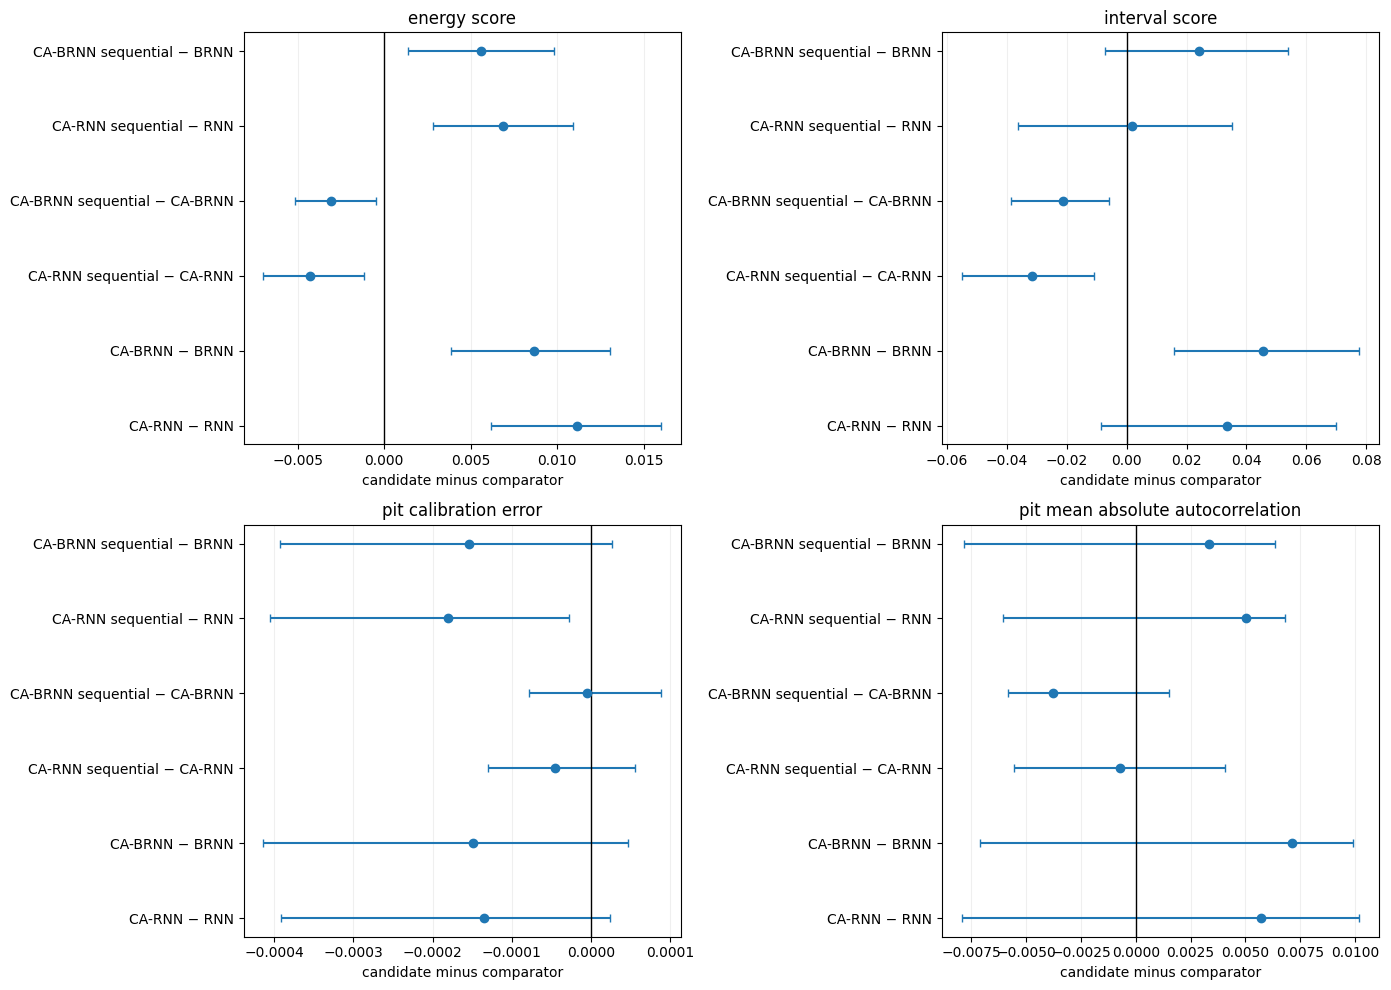

In [5]:
plot_metrics = ['energy_score', 'interval_score', 'pit_calibration_error', 'pit_mean_absolute_autocorrelation']
figure_data = primary.loc[primary.metric.isin(plot_metrics)].copy()
figure_data['comparison'] = figure_data.candidate + ' − ' + figure_data.comparator
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, metric in zip(axes.flat, plot_metrics):
    subset = figure_data.loc[figure_data.metric.eq(metric)].reset_index(drop=True)
    lower = subset.difference - subset.ci_lower
    upper = subset.ci_upper - subset.difference
    axis.errorbar(subset.difference, range(len(subset)), xerr=[lower, upper], fmt='o', capsize=3)
    axis.axvline(0, color='black', linewidth=1)
    axis.set_yticks(range(len(subset)), subset.comparison)
    axis.set_title(metric.replace('_', ' '))
    axis.set_xlabel('candidate minus comparator')
    axis.grid(axis='x', alpha=0.2)
plt.tight_layout()
fig.savefig(OUT / 'financial_paired_intervals.png', dpi=180, bbox_inches='tight')

In [6]:
loss_metrics = {'mean_squared_error', 'energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error', 'pit_mean_absolute_autocorrelation'}
decisions = primary.assign(interval_excludes_zero=(primary.ci_lower > 0) | (primary.ci_upper < 0))
decisions['direction'] = 'descriptive'
is_loss = decisions.metric.isin(loss_metrics)
decisions.loc[is_loss & (decisions.ci_upper < 0), 'direction'] = 'candidate favored'
decisions.loc[is_loss & (decisions.ci_lower > 0), 'direction'] = 'comparator favored'
decisions.loc[is_loss & ~decisions.interval_excludes_zero, 'direction'] = 'unresolved'
display(decisions[['candidate', 'comparator', 'metric', 'difference', 'ci_lower', 'ci_upper', 'direction']])
decisions.to_csv(OUT / 'financial_interval_decisions.csv', index=False)

,candidate,comparator,metric,difference,ci_lower,ci_upper,direction
0,CA-RNN,RNN,mean_squared_error,0.019606,0.010583,0.029900,comparator favored
1,CA-RNN,RNN,energy_score,0.011135,0.006144,0.015992,comparator favored
2,CA-RNN,RNN,interval_score,0.033516,-0.008454,0.070056,unresolved
3,CA-RNN,RNN,interval_width,0.011815,-0.026370,0.056403,descriptive
4,CA-RNN,RNN,coverage,-0.000534,-0.007471,0.006670,descriptive
5,CA-RNN,RNN,coverage_error,0.000534,-0.006670,0.007471,unresolved
6,CA-RNN,RNN,pit_calibration_error,-0.000135,-0.000392,0.000024,unresolved
7,CA-RNN,RNN,pit_mean_absolute_autocorrelation,0.005729,-0.007940,0.010176,unresolved
8,CA-BRNN,BRNN,mean_squared_error,0.015737,0.007997,0.023385,comparator favored
9,CA-BRNN,BRNN,energy_score,0.008634,0.003880,0.013027,comparator favored


## Interpretation rules
- Differences are candidate minus comparator; negative values favor the candidate for loss metrics.
- A 95% interval containing zero is unresolved, not evidence of equality.
- Raw coverage and width are descriptive. `coverage_error` is absolute deviation from nominal 90% coverage and is a lower-is-better loss.
- PIT calibration and dependence are nonlinear statistics; their intervals are recomputed within every block resample.
- Compare block lengths 5, 20, and 60. Conclusions that reverse with block length are not robust.
- These intervals quantify uncertainty conditional on one fitted model and one historical path. They do not include neural-seed, architecture-selection, or market-regime uncertainty.
- Confirmatory claims still require fresh time splits or rolling origins and independently repeated simulations.

## Project-level checklist
- Did calibration-aware training improve calibration without unacceptable proper-score loss?
- Did the sequential penalty improve temporal calibration in simulation and finance?
- Did either benefit persist under frozen-model distribution shift?
- Are conclusions consistent between frequentist and Bayesian variants?
- Which conclusions survive block-length sensitivity?
- Are exploratory hyperparameter choices clearly separated from confirmatory results?